In [1]:
from IPython.display import display, HTML

display(HTML("""
<div style="
    display: flex;
    flex-direction: column;
    justify-content: center;
    align-items: center;
    text-align: center;
">

  <h1 style="margin-bottom: 20px;">
    NFL Win/Lose Prediction
  </h1>

  <p style="font-size: 20px; margin-bottom: 40px;">
     Regression Analysis
  </p>

  <p style="font-size: 16px; margin-bottom: 20px;">
    Nikita Jain, Charlie Peng, Yanchen Zhou
  </p>

  <p style="font-size: 16px; margin-bottom: 10px;">
    Final Project
  </p>

  <p style="font-size: 16px; margin-bottom: 40px;">
    Practical Machine Learning
  </p>

  <p style="font-size: 16px;">
    February 2026
  </p>

</div>

<div style="page-break-after: always;"></div>
"""))

In [26]:
# library load
import pandas as pd
import pyarrow
import numpy as np
import nflreadpy as nfl

from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings

### Data Load

Using data from nflverse's repository of NFL records, the subset of games played within the years of 1999 to 2024 is extracted and saved to our repository. Loading it from data/ now:

In [3]:
data = pd.read_csv('../data/raw_pbp_data.csv')
data.head()

,game_id,season,week,home_team,away_team,result,play_type,play_id,posteam,defteam,rush_attempt,pass_attempt,epa
0,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,kickoff,1,PHI,ARI,0.0,0.0,0.126818
1,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,pass,2,PHI,ARI,0.0,1.0,-0.561568
2,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,run,3,PHI,ARI,1.0,0.0,-0.641717
3,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,no_play,4,PHI,ARI,0.0,0.0,-0.723302
4,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,pass,5,PHI,ARI,0.0,1.0,0.212661


# Executive Summary

This project develops a predictive modeling framework to estimate the likelihood of a home team win in National Football League (NFL) games using historical game‑level statistics. Leveraging publicly available datasets from the nflverse repository, the analysis integrates offensive, defensive, and turnover‑related metrics to understand how in‑game performance indicators relate to game outcomes. 

Multiple machine learning approaches, including logistic regression, decision trees, and random forests, are evaluated to determine which method most effectively captures the patterns associated with victories and losses. The resulting models are trained on historical seasons and validated on held‑out game data to assess predictive accuracy and generalizability. Ultimately, this work demonstrates how structured football statistics can be leveraged to generate predictive insights, offering a data‑driven perspective on team performance and game outcome forecasting.

# Problem Statement/Research objective

The primary objective of this project is to determine whether historical NFL game statistics can be used to accurately predict if the home team will win or lose a given matchup. Using detailed game‑level data including points scored, yards gained, turnovers, interceptions, and other performance indicators, the project seeks to build and evaluate statistical and machine learning models capable of forecasting game outcomes.

Specifically, the research aims to:
- Identify which game attributes most strongly influence the probability of a home team win.
- Construct and compare multiple predictive models (logistic regression, random forests, MLPs) to determine which approach yields the highest accuracy.
- Assess model performance on unseen game data to evaluate real‑world predictive reliability.
- Explore whether a data‑driven approach can meaningfully anticipate game outcomes based on pre‑ and in‑game descriptive statistics.


# Exploratory Data Analysis

The dataset we will be using comprises of NFL game data on games played from 1999-2024. Each year comprises of one season of games, which is split into **weeks**. Each week constitutes a round of games between different teams, and the whole season constitutes of 18 weeks, during which each of the teams play 17 games and have one bye or off week with no game.

The below dataset contains all games recorded from 1999-2024:

In [4]:
len(data['game_id'].drop_duplicates())

6988

In [5]:
data.head()

,game_id,season,week,home_team,away_team,result,play_type,play_id,posteam,defteam,rush_attempt,pass_attempt,epa
0,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,kickoff,1,PHI,ARI,0.0,0.0,0.126818
1,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,pass,2,PHI,ARI,0.0,1.0,-0.561568
2,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,run,3,PHI,ARI,1.0,0.0,-0.641717
3,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,no_play,4,PHI,ARI,0.0,0.0,-0.723302
4,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,pass,5,PHI,ARI,0.0,1.0,0.212661


We can explain what each of these columns means, using the first row as an example:

**game_id** — unique identifier for the game. 1999_01_ARI_PHI tells you season, week, and the two teams.

**season** — the NFL season year (1999).

**week** — week of the season (1 = opening week).

**home_team** — the team playing at their home stadium. PHI = Philadelphia Eagles are the home team here, meaning this game is in Philadelphia.

**away_team** — the visiting team. ARI = Arizona Cardinals traveling to play this game.

**result** — the final score margin from the home team's perspective. -1 means the home team (PHI) lost by 1 point.

**play_type** — what kind of play occurred: pass, run, no_play (penalty/timeout), or kickoff.

**play_id** - order in which the plays are made. This is the order to calculate any rolling averages.

**posteam** — the team on offense with possession. PHI has the ball for the first play.

**defteam** — the team on defense. ARI is defending on the first play.

**rush_attempt** — binary flag, 1 if it was a rushing play, 0 otherwise.

**pass_attempt** — binary flag, 1 if it was a passing play, 0 otherwise.

**epa** — Expected Points Added. Measures how much a play helped or hurt the offense relative to what was expected given the down, distance, and field position. Positive = good for offense, negative = bad, which means the first play's pass (-0.56) lost about half a point of expected value for PHI.

The EPA is the most important aspect for our analysis, and will be used to set a temporal view of the performance of each team.

Below, we can look at some summary statistics for the columns:

In [6]:
data.describe()

,season,week,result,play_id,rush_attempt,pass_attempt,epa
count,1.145828e+06,1.145828e+06,1.145828e+06,1.145828e+06,1.144630e+06,1.144630e+06,1.145814e+06
mean,2.011700e+03,9.569191e+00,2.258908e+00,8.296318e+01,3.237002e-01,4.404795e-01,-3.829627e-03
std,7.493290e+00,5.324770e+00,1.440618e+01,4.817880e+01,4.678874e-01,4.964449e-01,1.296353e+00
min,1.999000e+03,1.000000e+00,-4.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,-1.358486e+01
25%,2.005000e+03,5.000000e+00,-7.000000e+00,4.100000e+01,0.000000e+00,0.000000e+00,-5.706090e-01
50%,2.012000e+03,1.000000e+01,3.000000e+00,8.200000e+01,0.000000e+00,0.000000e+00,-5.451665e-02
75%,2.018000e+03,1.400000e+01,1.000000e+01,1.230000e+02,1.000000e+00,1.000000e+00,5.931511e-01
max,2.024000e+03,2.200000e+01,5.900000e+01,2.280000e+02,1.000000e+00,1.000000e+00,9.579869e+00


In [7]:
data['season'].value_counts().reset_index().sort_values('season').reset_index(drop=True)

,season,count
0,1999,40945
1,2000,40364
2,2001,42483
3,2002,44423
4,2003,43856
5,2004,43607
6,2005,43802
7,2006,43224
8,2007,43139
9,2008,42791


As we can see, the earliest recorded season in the dataset is from 1999, going on up until 2024.

In [8]:
print("Object columns: ")
data.dtypes[data.dtypes == 'object']

Object columns: 


game_id      object
home_team    object
away_team    object
play_type    object
posteam      object
defteam      object
dtype: object

In [9]:
print("Numeric columns: ")
data.dtypes[(data.dtypes == 'float64') | (data.dtypes == 'int64')]

Numeric columns: 


season            int64
week              int64
result            int64
play_id           int64
rush_attempt    float64
pass_attempt    float64
epa             float64
dtype: object

### Missing values

Missing values can be checked for quantity:

In [10]:
# check NaNs across columns
null_cols = pd.DataFrame(data.isnull().sum().sort_values(ascending=False), columns=['count'])
null_cols = null_cols[null_cols['count']>0]
null_cols['PerOfTotal'] = round(null_cols['count']*100/len(data), 2)
null_cols['VarName'] = null_cols.index
null_cols['VarType'] = null_cols['VarName'].apply(lambda x: data.dtypes[x])
null_cols = null_cols.drop(columns='VarName')

print(tabulate(null_cols, headers='keys', tablefmt='psql'))

+--------------+---------+--------------+-----------+
|              |   count |   PerOfTotal | VarType   |
|--------------+---------+--------------+-----------|
| posteam      |   45762 |         3.99 | object    |
| defteam      |   45762 |         3.99 | object    |
| rush_attempt |    1198 |         0.1  | float64   |
| pass_attempt |    1198 |         0.1  | float64   |
| epa          |      14 |         0    | float64   |
+--------------+---------+--------------+-----------+


The null columns above can be explained as below:

posteam, defteam - these fields are null for the non-scrimmage plays - where secondary teams come in to play instead of the offensive/defensive teams, which are the focus of our investigation. The null rows correspond to kickoffs, punts, and similar special teams plays where posteam/defteam aren't assigned in the same way.

rush_attempt, pass_attempt - these are administrative rows that exist between plays. Things like end-of-quarter rows, timeout rows, kickoff rows. They have no values because no play is happening at those times.

In [11]:
null_play_type = data.isnull().groupby([data['play_type']]).sum()
null_play_type

,game_id,season,week,home_team,away_team,result,play_type,play_id,posteam,defteam,rush_attempt,pass_attempt,epa
play_type,,,,,,,,,,,,,
field_goal,0,0,0,0,0,0,0,0,0,0,0,0,0
kickoff,0,0,0,0,0,0,0,0,0,0,0,0,0
no_play,0,0,0,0,0,0,0,0,45762,45762,1198,1198,0
pass,0,0,0,0,0,0,0,0,0,0,0,0,2
punt,0,0,0,0,0,0,0,0,0,0,0,0,0
run,0,0,0,0,0,0,0,0,0,0,0,0,12


As we can see above, posteam and defteam are only null when the play type is 'no_play' - i.e., there was no offensive or defensive play happening, which makes those rows irrelevant to our investigation.

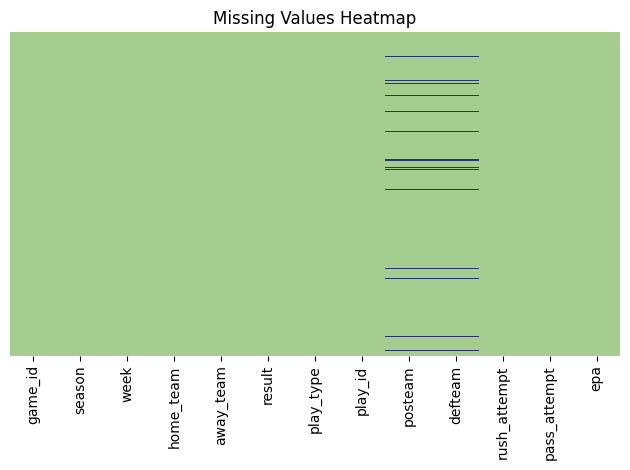

In [12]:
heatmap_df = data.copy()
for col in heatmap_df.select_dtypes(include=["object", "category"]).columns:
    heatmap_df[col] = heatmap_df[col].astype("category").cat.codes
    heatmap_df[col] = heatmap_df[col].replace(-1, np.nan)

sns.heatmap(heatmap_df.isnull(), cbar=False, cmap="crest", yticklabels=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

Our analysis for the null values is confirmed through the heatmap - posteam, defteam are null for the same rows (where no offensive or defensive play is happening), which is also the case for rush_attempt and pass_attempt. We can drop those rows as it is not relevant to our investigation.

For epa, it could be null for plays where EPA couldn't be computed. We can fill those rows with 0.

In [13]:
data['epa'] = data['epa'].fillna(0)
data = data.dropna()
data.shape

(1098868, 13)

### Negative Values

We can check for negative values present in the dataset below:

In [14]:
num_cols = data.select_dtypes(include=["int32","int64","float64","Int64"]).columns

neg_counts = ((data[num_cols] < 0)).sum().sort_values(ascending=False)
neg_counts = neg_counts[neg_counts > 0]
neg_counts

epa       594868
result    478356
dtype: int64

Here, the negative values have meaning that is important to our analysis.

EPA has negative values because every play is a zero-sum contest between offense and defense, so for every play that gains expected points for the offense, there are also plays that lose them. Bad throws, stuffed runs, sacks, penalties, all produce negative EPA. 

Result has negative values for the games where the home team loses the game. This is duplicated across each of the play rows for every single game, which is why the number looks big.

We can look at a full play-by-play example for one of the games played by the Chicago Bears below:

In [15]:
game = data[data['game_id']=='2023_01_GB_CHI']
game

,game_id,season,week,home_team,away_team,result,play_type,play_id,posteam,defteam,rush_attempt,pass_attempt,epa
1054126,2023_01_GB_CHI,2023,1,CHI,GB,-18,kickoff,1,CHI,GB,0.0,0.0,-0.938167
1054127,2023_01_GB_CHI,2023,1,CHI,GB,-18,run,2,CHI,GB,1.0,0.0,-0.617917
1054128,2023_01_GB_CHI,2023,1,CHI,GB,-18,pass,3,CHI,GB,0.0,1.0,1.958483
1054129,2023_01_GB_CHI,2023,1,CHI,GB,-18,pass,4,CHI,GB,0.0,1.0,0.122274
1054130,2023_01_GB_CHI,2023,1,CHI,GB,-18,run,5,CHI,GB,1.0,0.0,0.092138
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1054291,2023_01_GB_CHI,2023,1,CHI,GB,-18,pass,166,CHI,GB,0.0,1.0,-0.150869
1054292,2023_01_GB_CHI,2023,1,CHI,GB,-18,pass,167,CHI,GB,0.0,1.0,0.419973
1054293,2023_01_GB_CHI,2023,1,CHI,GB,-18,pass,168,CHI,GB,0.0,1.0,-0.273643
1054294,2023_01_GB_CHI,2023,1,CHI,GB,-18,pass,169,CHI,GB,0.0,1.0,-0.128739


In the first game of the 2023 NFL season, the Chicago Bears lost against the Green Bay Packers 20-38 - which is confirmed by our -18 result above.

![CB vs GB 2023 Week 1](../data/2023_week1_gb_cb.jpg)

### Feature Analysis

We can construct a quick correlation matrix for the numeric variables present, and look at some distributions:

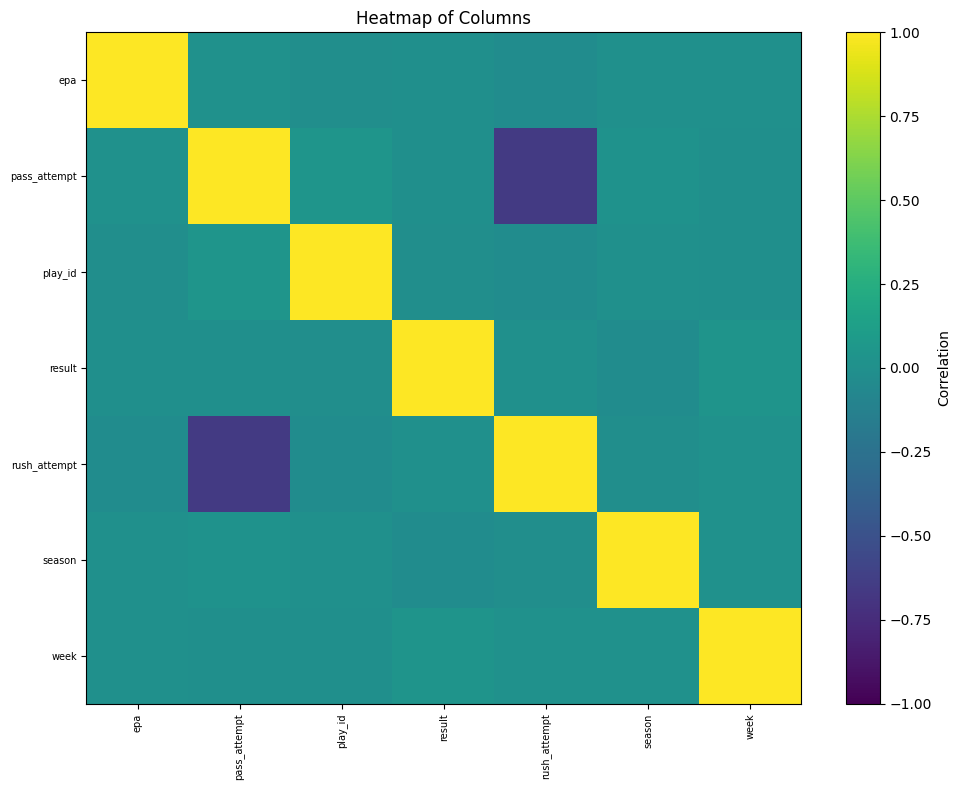

In [16]:
corr = data.corr(numeric_only=True)

pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=lambda s: s.abs(), ascending=False)
)

top_k_pairs = 20  
top_pairs = pairs.head(top_k_pairs)

top_cols = sorted(set([i for i, j in top_pairs.index] + [j for i, j in top_pairs.index]))

subcorr = corr.loc[top_cols, top_cols]

plt.figure(figsize=(10, 8))
plt.imshow(subcorr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title(f"Heatmap of Columns")

plt.xticks(range(len(top_cols)), top_cols, rotation=90, fontsize=7)
plt.yticks(range(len(top_cols)), top_cols, fontsize=7)

plt.tight_layout()
plt.show()

**pass_attempt** and **rush_attempt** have a stronger negative correlation, which is expected - on any given scrimmage play, it's either a pass or a run, so thr negative correlation makes sense.

The rest of the variable do not have much correlation between them - none of them have an above average correlation with result, even EPA. This makes sense as the **EPA for a single play does not tell us much** about the end result of the game, and it is only as we observe the **EPA over the course of the game**, in a rolling window of sorts, that we expect it to show influence over the result.

At the end of our preliminary analysis, we can preserve the final play-by-play data with the relevant columns:

In [17]:
# filter for the necessary play_types
plays = data[
    data['play_type'].isin(['pass', 'run', 'no_play']) &
    data['epa'].notna() &
    data['posteam'].notna() &
    data['result'].notna()
].copy()

print(f"Plays: {len(plays):,}")
print(f"Seasons: {plays['season'].min()} - {plays['season'].max()}")
print(f"Unique games: {plays['game_id'].nunique():,}")

Plays: 938,500
Seasons: 1999 - 2024
Unique games: 6,988


## Feature Distributions

Below, a few visualizations are shown to observe the make-up of the play-by-play data:

In [18]:
visual_df = plays.copy()
visual_df.columns

Index(['game_id', 'season', 'week', 'home_team', 'away_team', 'result',
       'play_type', 'play_id', 'posteam', 'defteam', 'rush_attempt',
       'pass_attempt', 'epa'],
      dtype='object')

In [19]:
#visual_df.to_csv('../data/intermediate_plays.csv', index=False)

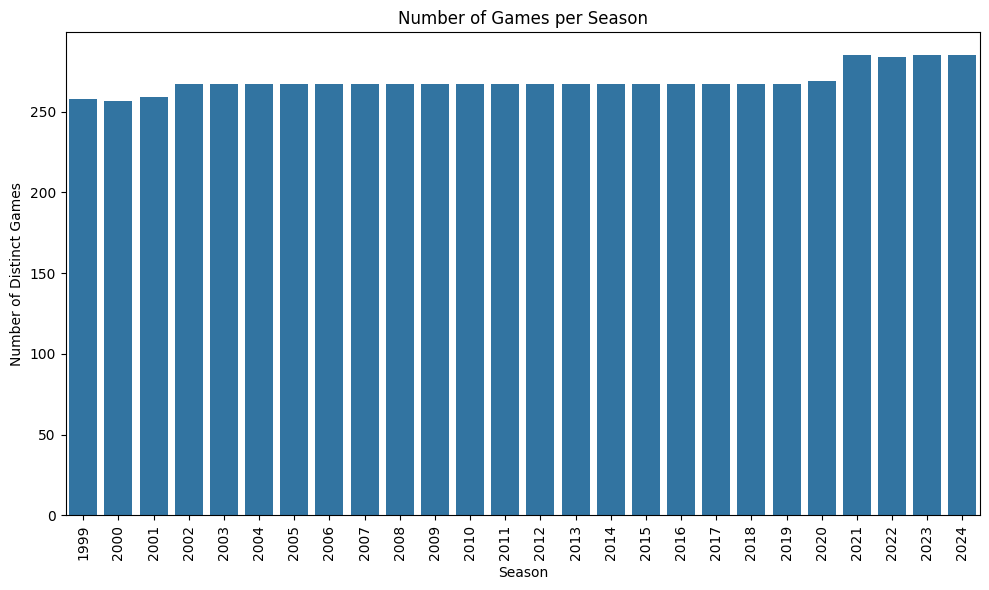

In [21]:
num_games_per_season = visual_df.groupby('season')['game_id'].apply(lambda x: x.nunique()).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=num_games_per_season, x="season", y="game_id", ax=ax)

ax.set_xlabel("Season")
ax.set_ylabel("Number of Distinct Games")
ax.set_title("Number of Games per Season")
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

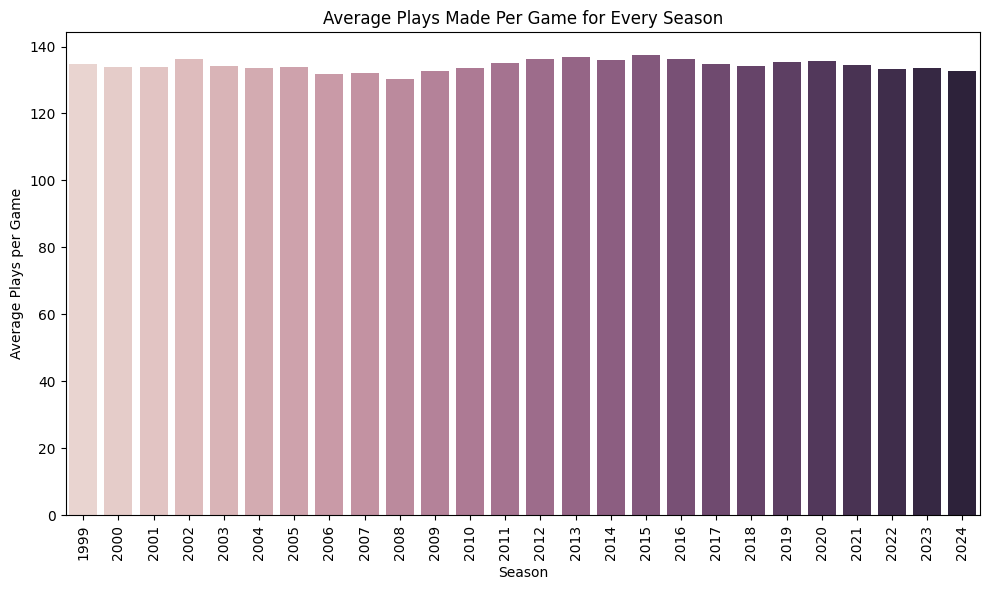

In [22]:
avg_plays = visual_df.groupby(['season','game_id'])['play_id'].apply(lambda x: x.nunique()).reset_index()
avg_plays = avg_plays.groupby('season')['play_id'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=avg_plays, x="season", y="play_id", ax=ax, hue='season', legend=False)

ax.set_xlabel("Season")
ax.set_ylabel("Average Plays per Game")
ax.set_title("Average Plays Made Per Game for Every Season")
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

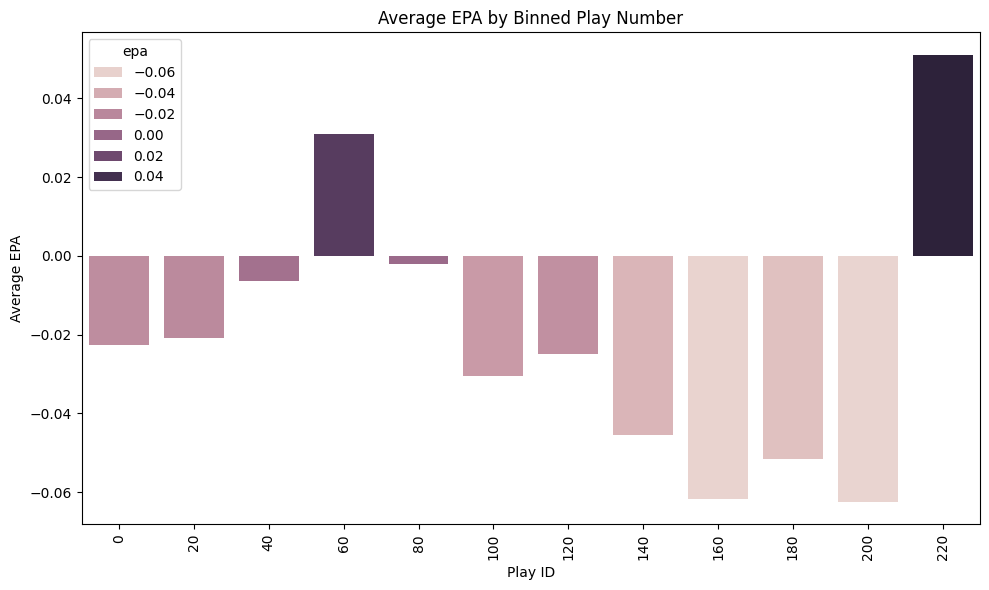

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

visual_df["play_id_bin"] = (visual_df["play_id"] // 20) * 20
epa_by_bin = visual_df.groupby("play_id_bin")["epa"].mean().reset_index()

sns.barplot(data=epa_by_bin, x="play_id_bin", y="epa", ax=ax, hue='epa')

ax.set_xlabel("Play ID")
ax.set_ylabel("Average EPA")
ax.set_title("Average EPA by Binned Play Number")
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

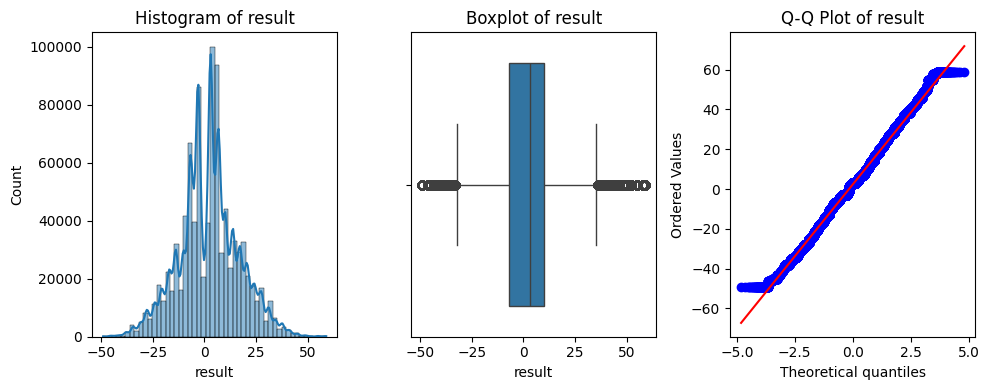

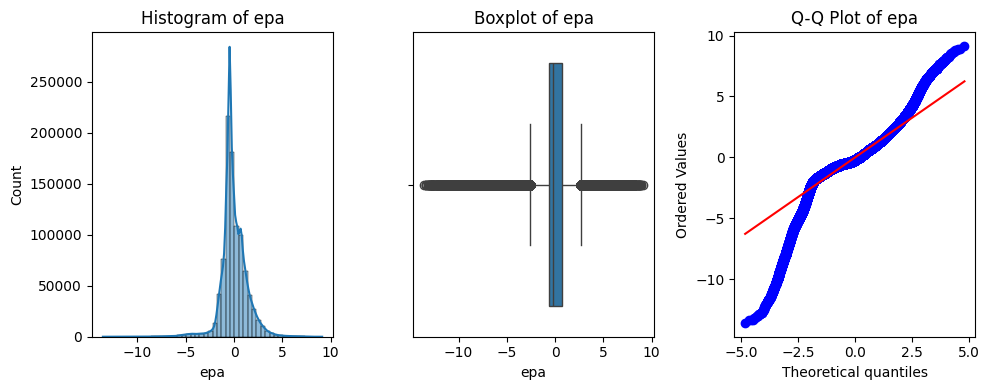

In [24]:
quant_cols = ['result','epa']
for col in quant_cols:
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    sns.histplot(visual_df[col], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')

    sns.boxplot(x=visual_df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    stats.probplot(visual_df[col].dropna(), dist="norm", plot=axes[2])
    axes[2].set_title(f'Q-Q Plot of {col}')

    plt.tight_layout()
    plt.show()

The two continuous columns, epa and result, have approximately normally shaped distributions with some outliers. epa shows more of a left skew due to the presence of more extreme values.

## Feature Creation

From our prior research and the above analysis, we have decided to create additional features based off of the concept of EPA.

Every play in football is worth some expected number of points based on down, distance, field position, etc. EPA measures how much a play changes that expectation. A 20-yard gain on 3rd & 2 might add +3 EPA. A 3-yard loss might be -2 EPA.

Positive EPA = good for the offense on that play

Negative EPA = bad for the offense (good for the defense)

EPA is preferred over simple stats like yards because it accounts for context - a 5-yard gain on 4th & 4 is far more valuable than a 5-yard gain on 1st & 10.

To give EPA meaning, we will create rolling average windows for the EPA for each of the games. We will also separate the offense and defense so that we can measure the impact of offensive and defensive moves on the teams playing each game.

---

For each team, per season per week, we compute mean EPA for:

Rush offense (posteam on rush_attempt plays)

Pass offense (posteam on pass_attempt plays)

Rush defense (defteam on rush_attempt plays)

Pass defense (defteam on pass_attempt plays)


In [25]:
# creating epa windows per game for each week's game
ro_epa = plays.loc[plays['rush_attempt'] == 1].groupby(['posteam', 'season', 'week'], as_index=False)['epa'].mean()

rd_epa = plays.loc[plays['rush_attempt'] == 1].groupby(['defteam', 'season', 'week'], as_index=False)['epa'].mean()

po_epa = plays.loc[plays['pass_attempt'] == 1].groupby(['posteam', 'season', 'week'], as_index=False)['epa'].mean()

pd_epa = plays.loc[plays['pass_attempt'] == 1].groupby(['defteam', 'season', 'week'], as_index=False)['epa'].mean()

# lag one period within each team 
ro_epa['epa_lagged'] = ro_epa.groupby('posteam')['epa'].shift()
rd_epa['epa_lagged'] = rd_epa.groupby('defteam')['epa'].shift()
po_epa['epa_lagged'] = po_epa.groupby('posteam')['epa'].shift()
pd_epa['epa_lagged'] = pd_epa.groupby('defteam')['epa'].shift()


These stats are then lagged/shifted by 1 week within each team, and this lagged information is then used to define the weekly **exponentially weighted moving average** (EWMA) EPA for both the offensive and defensive teams.

The EWMA is a way of averaging a team's EPA over time where recent games matter more than older ones. This is important when looking at temporal performance data like NFL plays - a team's performance last week is a better sign of how good or bad they are right now compared to their performance 10 weeks ago.

In [27]:
warnings.filterwarnings("ignore")
def ewma(x):
    # Calculate rolling exponentially weighted EPA
    values = np.zeros(len(x))
    epa_col = x['epa_lagged'].values
    week_col = x['week'].values
    for i in range(len(x)):
        epa_slice = pd.Series(epa_col[:i+1])
        span = max(int(week_col[i]), 10)
        values[i] = epa_slice.ewm(min_periods=1, span=span).mean().iloc[-1]

    return pd.Series(values, index=x.index)

ro_epa['ewma'] = ro_epa.groupby('posteam').apply(ewma).values
rd_epa['ewma'] = rd_epa.groupby('defteam').apply(ewma).values
po_epa['ewma'] = po_epa.groupby('posteam').apply(ewma).values
pd_epa['ewma'] = pd_epa.groupby('defteam').apply(ewma).values

In [28]:
# merge offense and defense into one EPA table per team
off_epa = ro_epa.merge(
    po_epa, on=['posteam', 'season', 'week'], suffixes=('_rushing', '_passing')).rename(columns={'posteam': 'team'})

def_epa = rd_epa.merge(
    pd_epa, on=['defteam', 'season', 'week'], suffixes=('_rushing', '_passing')).rename(columns={'defteam': 'team'})

epa = off_epa.merge(
    def_epa, on=['team', 'season', 'week'], suffixes=('_offense', '_defense'))

# drop first season as there is no previous season to get lag
epa = epa.loc[epa['season'] != epa['season'].unique()[0]].reset_index(drop=True)

print(f"EPA table shape: {epa.shape}")
print(f"Seasons: {epa['season'].min()} – {epa['season'].max()}")

EPA table shape: (13460, 15)
Seasons: 2000 – 2024


The EPA table now has the **rushing and passing EPA**, **shifted rushing and shifted passing EPA** and both **rushing and passing EWMA** for the **offensive** and **defensive** plays made by **each team for each game in each season**, across all seasons from 2000 to 2024.

In [29]:
epa.head()

,team,season,week,epa_rushing_offense,epa_lagged_rushing_offense,ewma_rushing_offense,epa_passing_offense,epa_lagged_passing_offense,ewma_passing_offense,epa_rushing_defense,epa_lagged_rushing_defense,ewma_rushing_defense,epa_passing_defense,epa_lagged_passing_defense,ewma_passing_defense
0,ARI,2000,1,-0.345669,-0.068545,-0.107735,0.019830,0.058749,-0.160557,0.166199,0.363190,0.101867,-0.009584,0.269840,0.117912
1,ARI,2000,2,-0.285129,-0.345669,-0.152471,0.558977,0.019830,-0.126640,-0.069123,0.166199,0.113962,0.283460,-0.009584,0.093940
2,ARI,2000,4,-0.334533,-0.285129,-0.177260,-0.270195,0.558977,0.001476,-0.018524,-0.069123,0.079751,0.500345,0.283460,0.129354
3,ARI,2000,5,-0.017570,-0.334533,-0.206501,0.049141,-0.270195,-0.049034,0.004774,-0.018524,0.061479,0.058499,0.500345,0.198331
4,ARI,2000,6,-0.038473,-0.017570,-0.171518,0.101830,0.049141,-0.030856,0.089185,0.004774,0.050979,-0.063633,0.058499,0.172439


We can now merge the information in the EPA table with the original dataset to get the win/lose result for each of these games.

In [30]:
# make the schedule of games for all games, and create target binary variable
schedule = plays[['game_id', 'season', 'week', 'home_team', 'away_team', 'result']].drop_duplicates(subset='game_id').reset_index(drop=True)

# home_win: 1 if home team won, 0 if away team won
schedule = schedule[schedule['result'] != 0].copy()
schedule['home_win'] = (schedule['result'] > 0).astype(int)

In [31]:
# schedule
schedule.head()

,game_id,season,week,home_team,away_team,result,home_win
0,1999_01_ARI_PHI,1999,1,PHI,ARI,-1,0
1,1999_01_BUF_IND,1999,1,IND,BUF,17,1
2,1999_01_CAR_NO,1999,1,NO,CAR,9,1
3,1999_01_CIN_TEN,1999,1,TEN,CIN,1,1
4,1999_01_DAL_WAS,1999,1,WAS,DAL,-6,0


In [32]:
# final dataset
EPA_COLS = [
    'ewma_rushing_offense',
    'ewma_passing_offense',
    'ewma_rushing_defense',
    'ewma_passing_defense',
]

epa_filt = epa[['team', 'season', 'week'] + EPA_COLS]

# merge home team EPA 
home_epa = epa_filt.rename(columns={
    'team': 'home_team',
    **{c: f'home_{c}' for c in EPA_COLS}
})

# merge away team EPA 
away_epa = epa_filt.rename(columns={
    'team': 'away_team',
    **{c: f'away_{c}' for c in EPA_COLS}
})

final_df = schedule.merge(home_epa, on=['home_team', 'season', 'week'], how='inner').merge(away_epa, on=['away_team', 'season', 'week'], how='inner').dropna()
final_df['home_win'] = final_df['home_win'].astype('category')

print(f"Final Dataset shape with first season dropped due to no lag: {final_df.shape}")
final_df.head()

Final Dataset shape with first season dropped due to no lag: (6715, 15)


,game_id,season,week,home_team,away_team,result,home_win,home_ewma_rushing_offense,home_ewma_passing_offense,home_ewma_rushing_defense,home_ewma_passing_defense,away_ewma_rushing_offense,away_ewma_passing_offense,away_ewma_rushing_defense,away_ewma_passing_defense
0,2000_01_ARI_NYG,2000,1,NYG,ARI,5,1,-0.106167,0.024206,-0.121652,0.142602,-0.107735,-0.160557,0.101867,0.117912
1,2000_01_BAL_PIT,2000,1,PIT,BAL,-16,0,-0.107052,-0.112561,-0.038684,0.010816,-0.084005,-0.134384,-0.203422,-0.211485
2,2000_01_CAR_WAS,2000,1,WAS,CAR,3,1,-0.059887,-0.002951,-0.151454,-0.082001,-0.247680,0.197692,0.070962,0.005273
3,2000_01_CHI_MIN,2000,1,MIN,CHI,3,1,-0.061235,0.163552,-0.220936,0.148003,-0.177805,-0.046987,-0.047161,0.102908
4,2000_01_DEN_STL,2000,1,LA,DEN,5,1,-0.243058,0.295541,-0.112013,-0.117652,-0.094039,-0.016540,-0.084653,-0.084698


## Target Variable - Home Win

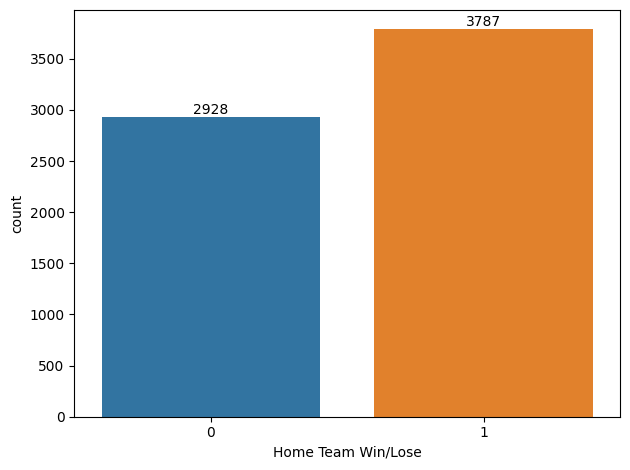

In [33]:
ax = sns.countplot(x='home_win', data=final_df, hue='home_win', legend=False)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_xlabel("Home Team Win/Lose")
plt.tight_layout()
plt.show();

In [34]:
print(f"Total games: {len(final_df):,}")
print(f"Home win rate: {final_df['home_win'].astype(int).sum()/len(final_df):.3f}")

Total games: 6,715
Home win rate: 0.564


It looks like the home team wins 56.4% of the time

The distribution of the final dataset is not perfectly balanced but not imbalanced enough to cause outright issues in classification. We will ensure awareness of this when modeling.

In [32]:
# save final data
final_df.to_csv('../data/final_dataset.csv', index=False)